In [ ]:
!pip install gdown

import gdown

# URL of the file
url = 'https://drive.google.com/uc?id=1WWgvtxTDc5KuWuCQS8ca2YzPj9B9X66c'
output = 'afaan_oromo_text.txt'

# Download the file
gdown.download(url, output, quiet=False)

# Read the contents of the file
with open(output, 'r', encoding='utf-8') as file:
    text_data = file.read()

print("Text data loaded successfully.")

Downloading...
From: https://drive.google.com/uc?id=1WWgvtxTDc5KuWuCQS8ca2YzPj9B9X66c
To: /content/afaan_oromo_text.txt
100%|██████████| 1.71M/1.71M [00:00<00:00, 150MB/s]

Text data loaded successfully.


In [ ]:
import gdown, nltk
from nltk.tokenize import sent_tokenize
# Download the 'punkt' resource
nltk.download('punkt')
# Tokenize text into sentences
sentences = sent_tokenize(text_data)

# Display the first 10 sentences
for i in range(10):
  #  print(f"Sentence {i+1}: {sentences[i]}")
    print(f"{i+1}: {sentences[i]}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


1: Humni qilleensaa Isiraa'el haleellaa misaayelaa fi ibbiddaa ciccimaa irra ga'eef deebii kennuuf holqoota gara gaazaa geessan irratti haleellaa ni bana.
2: "Seera haaraa waa'ee maq-balleessii amantiilee dhorku bahe duubatti dhiisuun namoonni waaqa-dhabeessi Aayerland itti yaaduun jechoota akka yesuus kiristoos,Muhammad, Saalmaan Rushdee, Maark Tiween, fi phaaphaasii Benediktii 16ffa faa tooraa marsariitii irratti maxxansan"

Hoggantoonni siyaasaa Beenin walakkaa ol tahan karoora dhoksaa Poontiitti hirmaachuu isaaf adeemsi aangoorraa buufamuu Pirasdaantii Boonii Yaayyaa akka eegalamu waamicha dhiyeessan.
3: "Hobonboleettiin Daani'eelle, hobonboleettii ijoo isa jalqabaa waqtii hobonboleettii Atilaantikii 2010 ta'uun gara Sadarkaa 4'tt guddate."
4: \
Moozambiki dabala gatii daabboo isa torban darbe jeequmsa kaase akka jijjiirtu beeksifte.
5: Jaappaan bidiruu qurxummii qabduu Chaayinaa isa bakka walfalmisiisaa Odola Pinaakilii kan Baha Galaana Chaayisaa keessaatti argame hiite.
6: Dhukaa

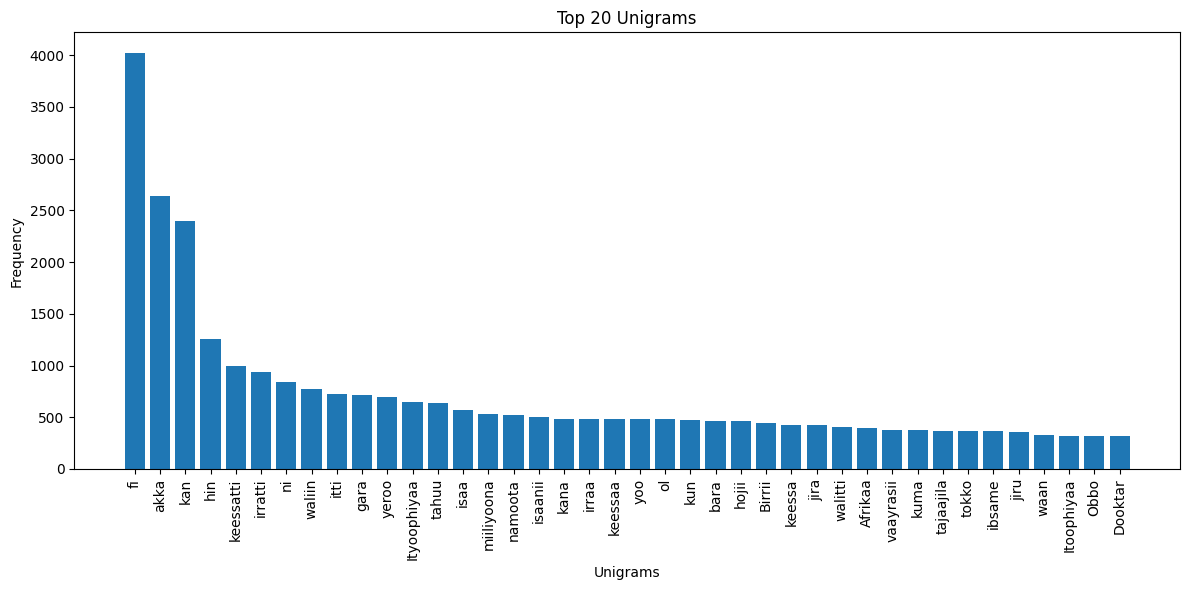

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
from nltk import ngrams

# Tokenize the text (assuming words are separated by spaces)
tokens = text_data.split()

# Unigrams
unigram_counts = Counter(tokens)
top_20_unigrams = unigram_counts.most_common(40)

# Bigrams
bigrams = ngrams(tokens, 2)
bigram_counts = Counter(bigrams)
top_20_bigrams = bigram_counts.most_common(40) #but i am using top 40

# Plotting unigrams
plt.figure(figsize=(12, 6))
plt.bar([word for word, count in top_20_unigrams], [count for word, count in top_20_unigrams])
plt.xlabel('Unigrams')
plt.ylabel('Frequency')
plt.title('Top 20 Unigrams')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


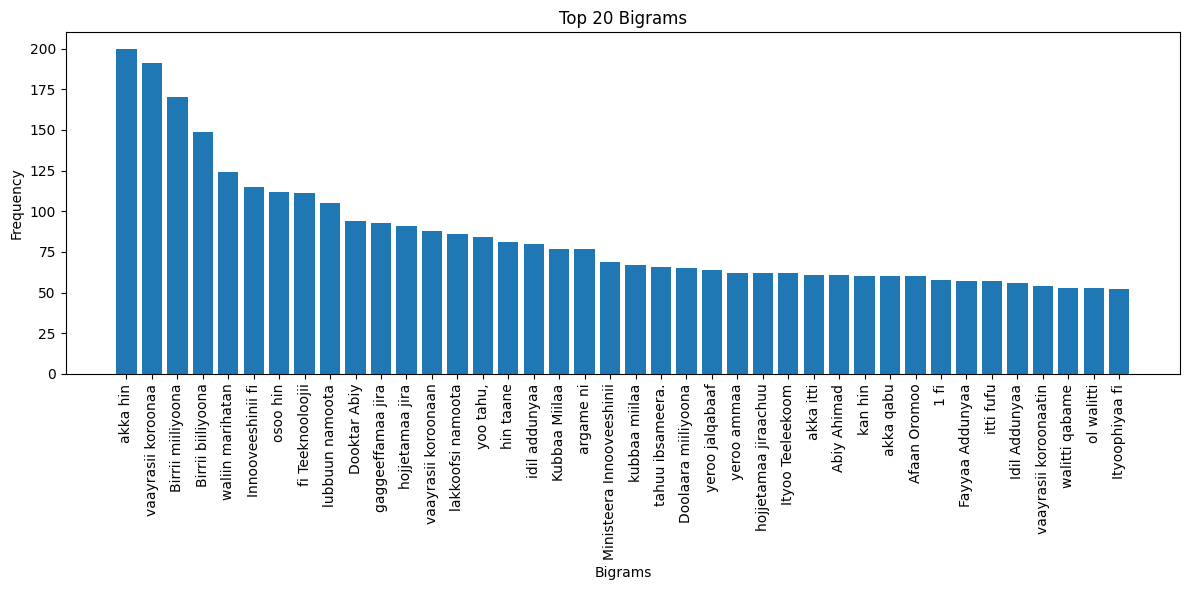

In [ ]:
# Plotting bigrams
plt.figure(figsize=(12, 6))
plt.bar([' '.join(bigram) for bigram, count in top_20_bigrams], [count for bigram, count in top_20_bigrams])
plt.xlabel('Bigrams')
plt.ylabel('Frequency')
plt.title('Top 20 Bigrams')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

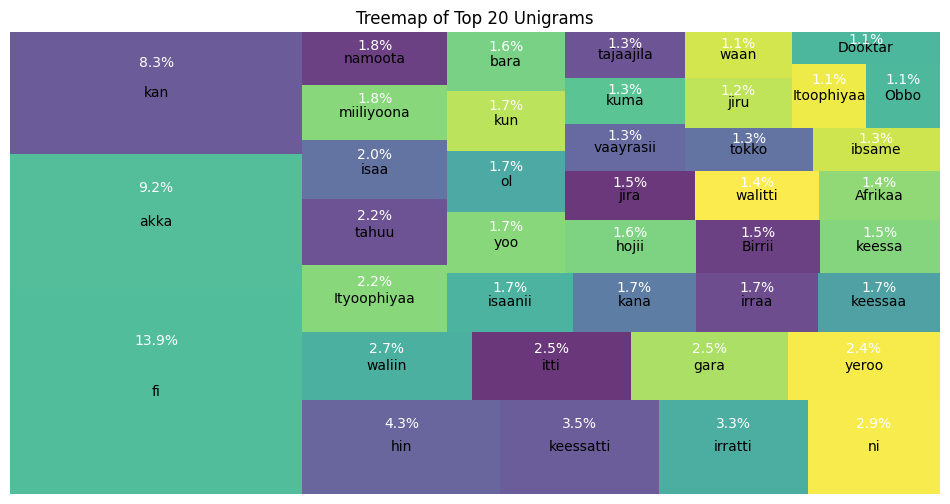

In [ ]:
import matplotlib.pyplot as plt
!pip install squarify # Install the missing module
import squarify

# Assuming top_20_unigrams is a list of (unigram, count) tuples
# Example:
# top_20_unigrams = [('data', 120), ('science', 100), ...]

# Calculate total count for percentage calculation
total_count = sum(count for unigram, count in top_20_unigrams)

# Extract sizes and labels
sizes = [count for unigram, count in top_20_unigrams]
labels = [unigram for unigram, count in top_20_unigrams]

# Plot the treemap
plt.figure(figsize=(12, 6))
ax = plt.gca()
squarify.plot(
    sizes=sizes,
    label=labels,
    alpha=.8,
    ax=ax
)

# Add percentage labels to each rectangle below the text
for i, rect in enumerate(ax.patches):
    # Calculate percentage for each unigram
    count = sizes[i]
    percentage = (count / total_count) * 100
    # Calculate the center of each rectangle
    x_center = rect.get_x() + rect.get_width() / 2
    y_center = rect.get_y() + rect.get_height() / 2
    # Calculate text position for percentage (slightly below the text)
    plt.text(
        x_center,  # x position of label
        y_center + rect.get_height() / 4,  # y position of label (below the text)
        f'{percentage:.1f}%',  # Label text with one decimal place
        ha='center',  # Horizontal alignment
        va='center',  # Vertical alignment
        color='white'  # Text color for visibility
    )
# Set up the plot title and remove the axes
plt.title('Treemap of Top 20 Unigrams')
plt.axis('off')  # Ensure that the axes are visible
plt.grid(True)  # Optional: Add grid lines for better readability

plt.show()

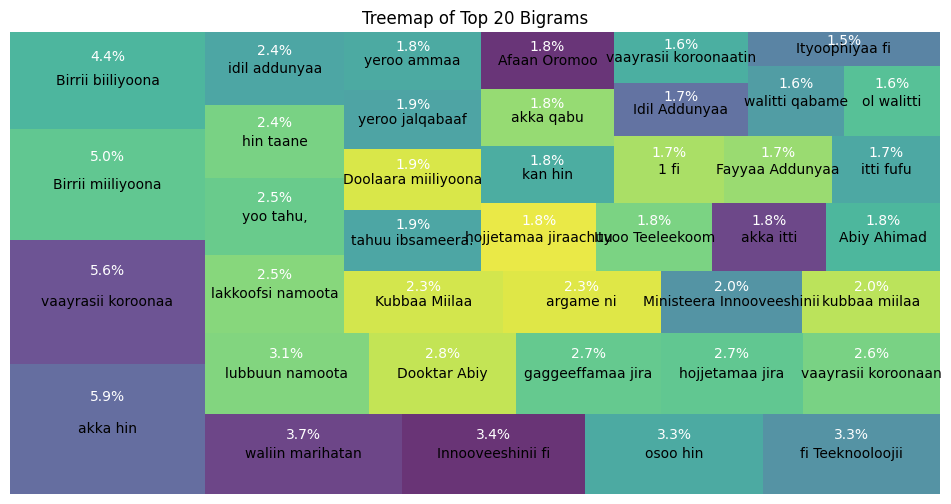

In [ ]:
import matplotlib.pyplot as plt
import squarify

# Assuming top_20_bigrams is a list of (bigram, count) tuples
# Example:
# top_20_bigrams = [(('data', 'science'), 120), (('machine', 'learning'), 100), ...]

# Calculate total count for percentage calculation
total_count = sum(count for bigram, count in top_20_bigrams)

# Extract sizes and labels
sizes = [count for bigram, count in top_20_bigrams]
labels = [' '.join(bigram) for bigram, count in top_20_bigrams]

# Plot the treemap
plt.figure(figsize=(12, 6))
ax = plt.gca()
squarify.plot(
    sizes=sizes,
    label=labels,
    alpha=.8,
    ax=ax
)

# Add percentage labels to each rectangle below the text
for i, rect in enumerate(ax.patches):
    # Calculate percentage for each bigram
    count = sizes[i]
    percentage = (count / total_count) * 100
    # Calculate the center of each rectangle
    x_center = rect.get_x() + rect.get_width() / 2
    y_center = rect.get_y() + rect.get_height() / 2
    # Calculate text position for percentage (slightly below the text)
    plt.text(
        x_center,  # x position of label
        y_center + rect.get_height() / 4,  # y position of label (below the text)
        f'{percentage:.1f}%',  # Label text with one decimal place
        ha='center',  # Horizontal alignment
        va='center',  # Vertical alignment
        color='white'  # Text color for visibility
    )

plt.title('Treemap of Top 20 Bigrams')
plt.axis('off')
plt.show()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.1/511.1 kB 3.3 MB/s eta 0:00:00


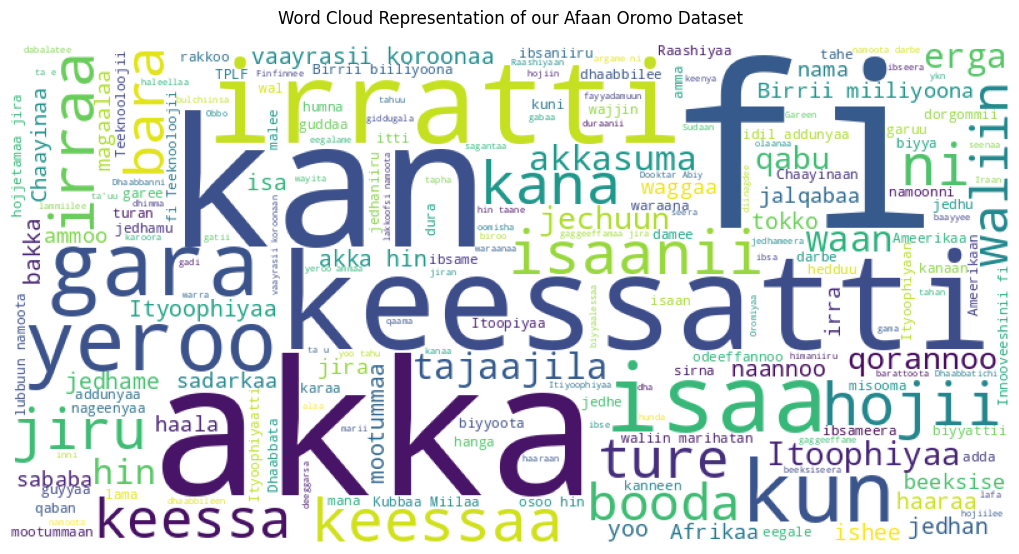

In [ ]:
# prompt: i want to create a word cloud graphical representation for the texts in this dataset
import matplotlib.pyplot as plt
!pip install wordcloud # Install the wordcloud module
from wordcloud import WordCloud

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_data)

# Display the generated image:
plt.figure(figsize=(10, 8), facecolor=None)
plt.imshow(wordcloud)
plt.title('Word Cloud Representation of our Afaan Oromo Dataset', fontsize=12, pad=15)  # Add a title with styling
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()


1. **Converting to lowercase and stripping multiple whitespaces.**
2. **Remove punctuation**
3. **Remove stopwords**
4. **Remove emojis**
5. **Lemmatization**
6. **Tokenization**
7. **Vectorization**


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# Preprocess the text data
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text_data])
total_words = len(tokenizer.word_index) + 1

# Create input sequences
input_sequences = []
for line in text_data.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

# Pad sequences and create predictors and labels
max_sequence_len = max([len(x) for x in input_sequences])
input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre'))
predictors, label = input_sequences[:,:-1], input_sequences[:,-1]
label = tf.keras.utils.to_categorical(label, num_classes=total_words)

**Bidirectional LSTM without Attension Mechanism** for Next word Prediction , **epoch = 50**

**Scored:**

*   accuracy: 0.7590
*   loss: 1.3402

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 85)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding_1 (Embedding)              │ (None, 85, 100)             │       1,492,300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 85, 200)             │         160,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_6 (LSTM)                        │ (None, 100)                 │         120,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 14923)               │       1,507,223 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,280,723 (12.51 MB)

 Trainable params: 3,280,723 (12.51 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/50
1508/1508 ━━━━━━━━━━━━━━━━━━━━ 45s 28ms/step - accuracy: 0.0194 - loss: 8.8745
Epoch 2/50
1508/1508 ━━━━━━━━━━━━━━━━━━━━ 80s 27ms/step - accuracy: 0.0221 - loss: 8.2739
Epoch 3/50
1508/1508 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.0227 - loss: 8.0861
Epoch 4/50
1508/1508 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.0274 - loss: 7.8721
Epoch 5/50
1508/1508 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.0341 - loss: 7.5647
Epoch 6/50
1508/1508 ━━━━━━━━━━━━━━━━━━━━ 40s 27ms/step - accuracy: 0.0419 - loss: 7.2610
Epoch 7/50
1508/1508 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.0524 - loss: 6.8725
Epoch 8/50
1508/1508 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.0665 - loss: 6.4824
Epoch 9/50
1508/1508 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.0814 - loss: 6.1331
Epoch 10/50
1508/1508 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.1007 - loss: 5.7508
Epoch 11/50
1508/1508 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.1176 - loss: 5.4215
Epo

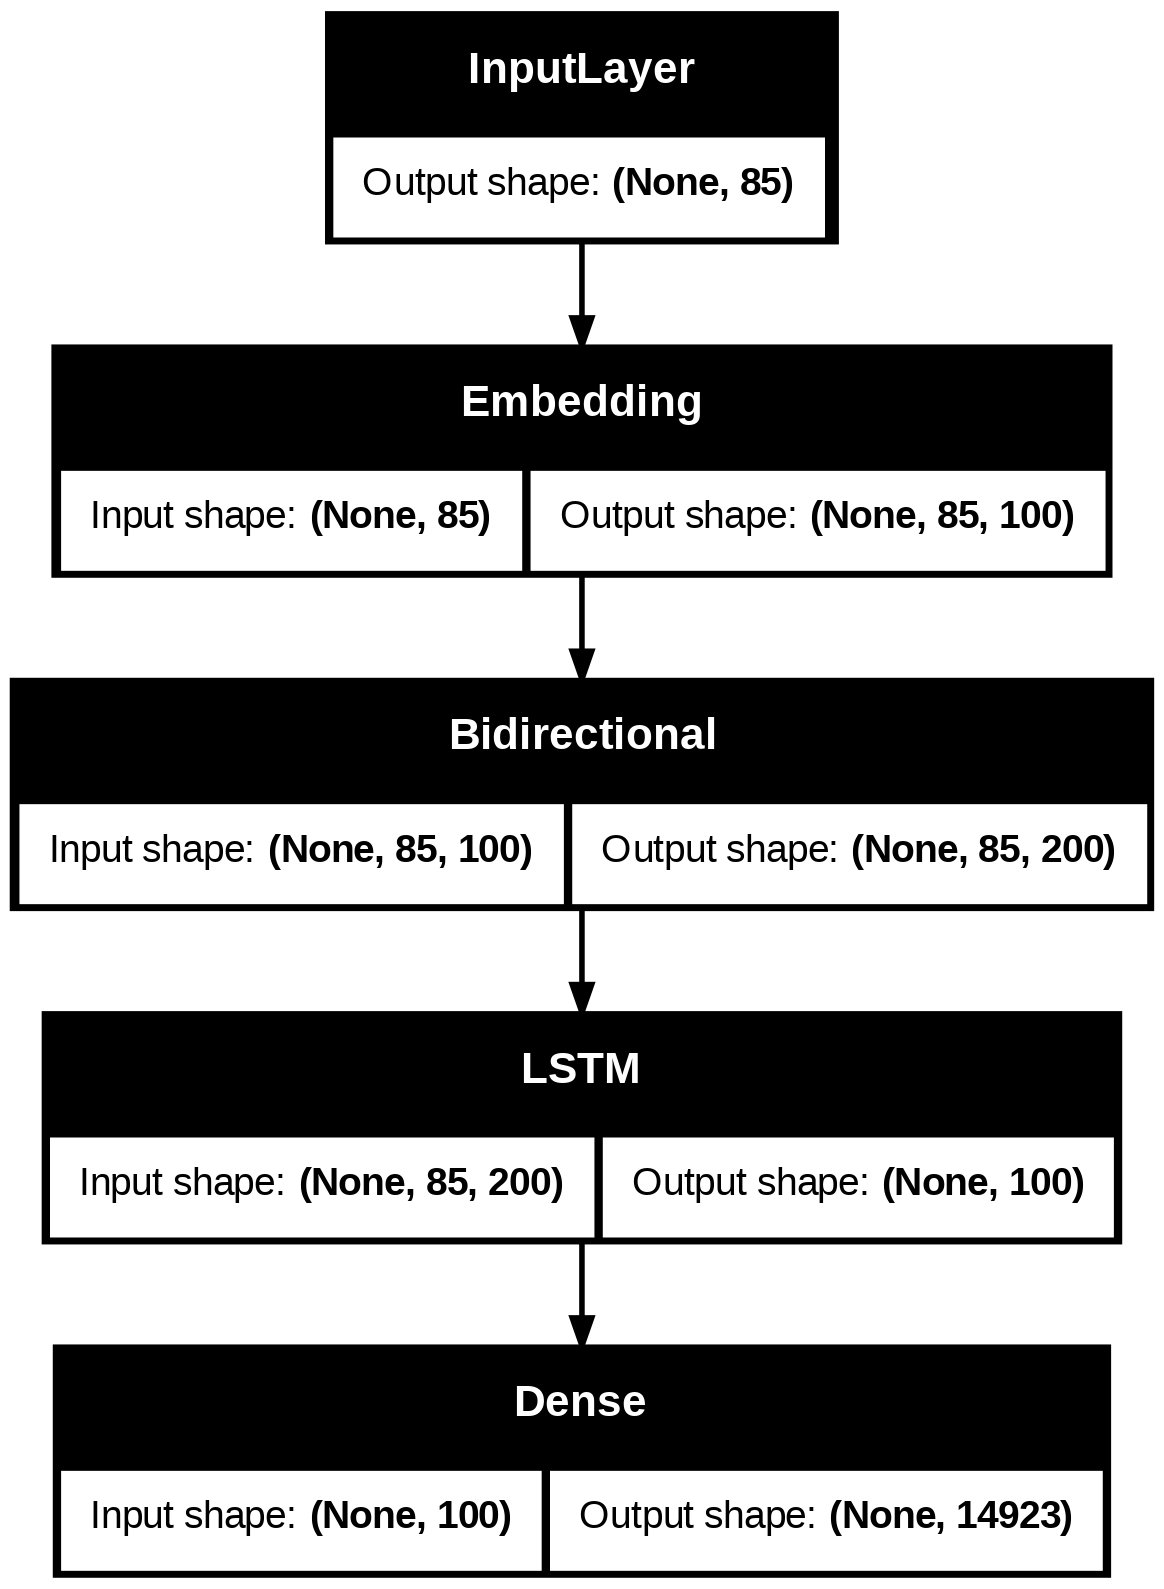

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Input
from tensorflow.keras.utils import to_categorical, plot_model

# Define input layer
input_seq = Input(shape=(max_sequence_len-1,))

# Embedding layer
embedding_layer = Embedding(total_words, 100)(input_seq)

# Bidirectional LSTM layer
bi_lstm_layer = Bidirectional(LSTM(100, return_sequences=True))(embedding_layer)

# Add another LSTM layer after the Bidirectional LSTM
final_lstm_layer = LSTM(100)(bi_lstm_layer)

# Dense output layer
output_layer = Dense(total_words, activation='softmax')(final_lstm_layer)

# Create and compile the model
model_BiLSTM = Model(inputs=input_seq, outputs=output_layer)
model_BiLSTM.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print(model_BiLSTM.summary())

# Train the model
model_BiLSTM.fit(predictors, label, epochs=50, verbose=1)

# Save the entire model to a single file
model_BiLSTM.save('my_model_BiLSTM.keras')

# Plot the model
plot_model(model_BiLSTM, to_file='model_BiLSTM_plot.png', show_shapes=True)

**Bidirectional LSTM with Attension Mechanism** for Next word Prediction , **epoch = 30**

**Scored:**

*   accuracy: 0.8379
*  loss: 0.9409

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Attention, Input, Concatenate
from tensorflow.keras.utils import to_categorical, plot_model

# ... (rest of your preprocessing code)

# Define input layer
input_seq = Input(shape=(max_sequence_len-1,))

# Embedding layer
embedding_layer = Embedding(total_words, 100)(input_seq)

# Bidirectional LSTM layer
bi_lstm_layer = Bidirectional(LSTM(100, return_sequences=True))(embedding_layer)   #150 origionally

# Define query, key, and value inputs for attention
query = LSTM(100, return_sequences=True)(bi_lstm_layer)
value = LSTM(100, return_sequences=True)(bi_lstm_layer)
key = LSTM(100, return_sequences=True)(bi_lstm_layer)

# Apply attention mechanism
attention_layer = Attention()([query, value])

# Concatenate the attention output with the LSTM output
concat_layer = Concatenate()([attention_layer, bi_lstm_layer])

# Add another LSTM layer after concatenation
final_lstm_layer = LSTM(100)(concat_layer)

# Dense output layer
output_layer = Dense(total_words, activation='softmax')(final_lstm_layer)

# Create and compile the model
model_ABiLSTM = Model(inputs=input_seq, outputs=output_layer)
model_ABiLSTM.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print(model_ABiLSTM.summary())

# Train the model
history_ABiLSTM = model_ABiLSTM.fit(predictors, label, epochs=30, verbose=1)
'''
# Save the entire model to a single file
model_ABiLSTM.save('my_model_ABiLSTM.keras')

# Plot the model
plot_model(model_ABiLSTM, to_file='model_ABiLSTM_plot.png', show_shapes=True)
'''

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 63)]                 0         []                            
                                                                                                  
 embedding (Embedding)       (None, 63, 100)              3490900   ['input_1[0][0]']             
                                                                                                  
 bidirectional (Bidirection  (None, 63, 200)              160800    ['embedding[0][0]']           
 al)                                                                                              
                                                                                                  
 lstm_1 (LSTM)               (None, 63, 100)              120400    ['bidirectional[0][0]']   

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Attention, Input, Concatenate
from tensorflow.keras.utils import to_categorical, plot_model

# ... (rest of your preprocessing code)

# Define input layer
input_seq = Input(shape=(max_sequence_len-1,))

# Embedding layer
embedding_layer = Embedding(total_words, 100)(input_seq)

# Bidirectional LSTM layer
bi_lstm_layer = Bidirectional(LSTM(100, return_sequences=True))(embedding_layer)   #150 origionally

# Define query, key, and value inputs for attention
query = LSTM(100, return_sequences=True)(bi_lstm_layer)
value = LSTM(100, return_sequences=True)(bi_lstm_layer)
key = LSTM(100, return_sequences=True)(bi_lstm_layer)

# Apply attention mechanism
attention_layer = Attention()([query, value])

# Concatenate the attention output with the LSTM output
concat_layer = Concatenate()([attention_layer, bi_lstm_layer])

# Add another LSTM layer after concatenation
final_lstm_layer = LSTM(100)(concat_layer)

# Dense output layer
output_layer = Dense(total_words, activation='softmax')(final_lstm_layer)

# Create and compile the model
model_ABiLSTM = Model(inputs=input_seq, outputs=output_layer)
model_ABiLSTM.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print(model_ABiLSTM.summary())

# Train the model
history_ABiLSTM = model_ABiLSTM.fit(predictors, label, epochs=30, verbose=1)
'''
# Save the entire model to a single file
model_ABiLSTM.save('my_model_ABiLSTM.keras')

# Plot the model
plot_model(model_ABiLSTM, to_file='model_ABiLSTM_plot.png', show_shapes=True)
'''

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 85)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_1 (Embedding)   │ (None, 85, 100)        │      1,492,300 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional             │ (None, 85, 200)        │        160,800 │ embedding_1[0][0]      │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_6 (LSTM)             │ (None, 85, 100)        │        120,400 │ bidirectional[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_7 (LSTM)             │ (None, 85, 100)        │        120,400 │ bidirectional[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attention_1 (Attention)   │ (None, 85, 100)        │              0 │ lstm_6[0][0],          │
│                           │                        │                │ lstm_7[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_1             │ (None, 85, 300)        │              0 │ attention_1[0][0],     │
│ (Concatenate)             │                        │                │ bidirectional[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_9 (LSTM)             │ (None, 100)            │        160,400 │ concatenate_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 14923)          │      1,507,223 │ lstm_9[0][0]           │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 3,561,523 (13.59 MB)

 Trainable params: 3,561,523 (13.59 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/30
1508/1508 ━━━━━━━━━━━━━━━━━━━━ 56s 35ms/step - accuracy: 0.0192 - loss: 8.8386
Epoch 2/30
1508/1508 ━━━━━━━━━━━━━━━━━━━━ 52s 35ms/step - accuracy: 0.0238 - loss: 8.2234
Epoch 3/30
1508/1508 ━━━━━━━━━━━━━━━━━━━━ 82s 35ms/step - accuracy: 0.0256 - loss: 8.0734
Epoch 4/30
1508/1508 ━━━━━━━━━━━━━━━━━━━━ 82s 35ms/step - accuracy: 0.0293 - loss: 7.8893
Epoch 5/30
1508/1508 ━━━━━━━━━━━━━━━━━━━━ 81s 34ms/step - accuracy: 0.0296 - loss: 7.6898
Epoch 6/30
1508/1508 ━━━━━━━━━━━━━━━━━━━━ 82s 35ms/step - accuracy: 0.0396 - loss: 7.3823
Epoch 7/30
1508/1508 ━━━━━━━━━━━━━━━━━━━━ 82s 35ms/step - accuracy: 0.0441 - loss: 7.0599
Epoch 8/30
1508/1508 ━━━━━━━━━━━━━━━━━━━━ 82s 35ms/step - accuracy: 0.0542 - loss: 6.7067
Epoch 9/30
1508/1508 ━━━━━━━━━━━━━━━━━━━━ 82s 35ms/step - accuracy: 0.0645 - loss: 6.3501
Epoch 10/30
1508/1508 ━━━━━━━━━━━━━━━━━━━━ 82s 35ms/step - accuracy: 0.0792 - loss: 5.9647
Epoch 11/30
1508/1508 ━━━━━━━━━━━━━━━━━━━━ 82s 35ms/step - accuracy: 0.0998 - loss: 5.5811
Epo

"\n# Save the entire model to a single file\nmodel_ABiLSTM.save('my_model_ABiLSTM.keras')\n\n# Plot the model\nplot_model(model_ABiLSTM, to_file='model_ABiLSTM_plot.png', show_shapes=True)\n"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


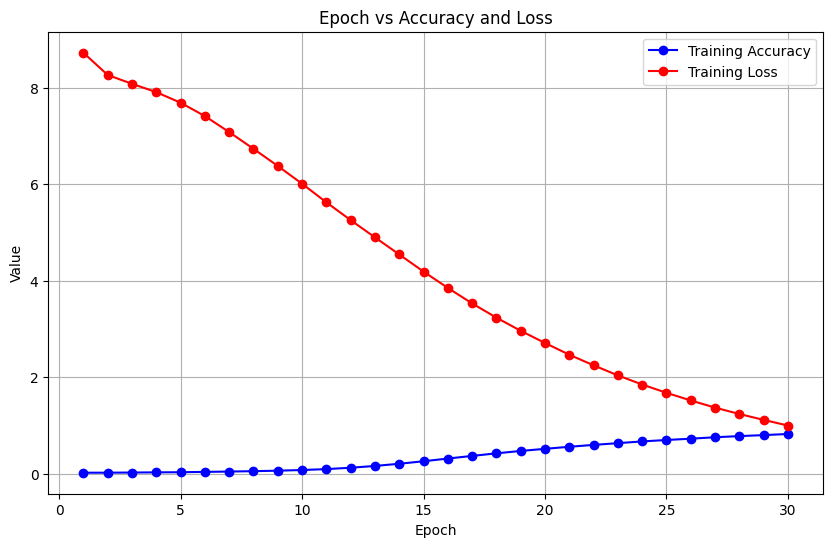

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
# Save the entire model to a single file
model_ABiLSTM.save('/content/drive/My Drive/my_model_ABiLSTM.keras')
model_ABiLSTM.save('my_model_ABiLSTM.keras')

# Now plot the model
from tensorflow.keras.utils import plot_model
plot_model(model_ABiLSTM, to_file='model_ABiLSTM_plot.png', show_shapes=True)
#plot_model(model_LSTM, to_file='/content/drive/My Drive/model_ALSTM_plot.png', show_shapes=True)


# Extract accuracy and loss values from the training history
accuracy = history_ABiLSTM.history['accuracy']
loss = history_ABiLSTM.history['loss']
epochs = range(1, len(accuracy) + 1)

# Create a figure and axis
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

# Plot Epoch vs. Accuracy and Loss on the same axis
plt.plot(epochs, accuracy, 'bo-', label='Training Accuracy')
plt.plot(epochs, loss, 'ro-', label='Training Loss')

# Add titles and labels
plt.title('Epoch vs Accuracy and Loss')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

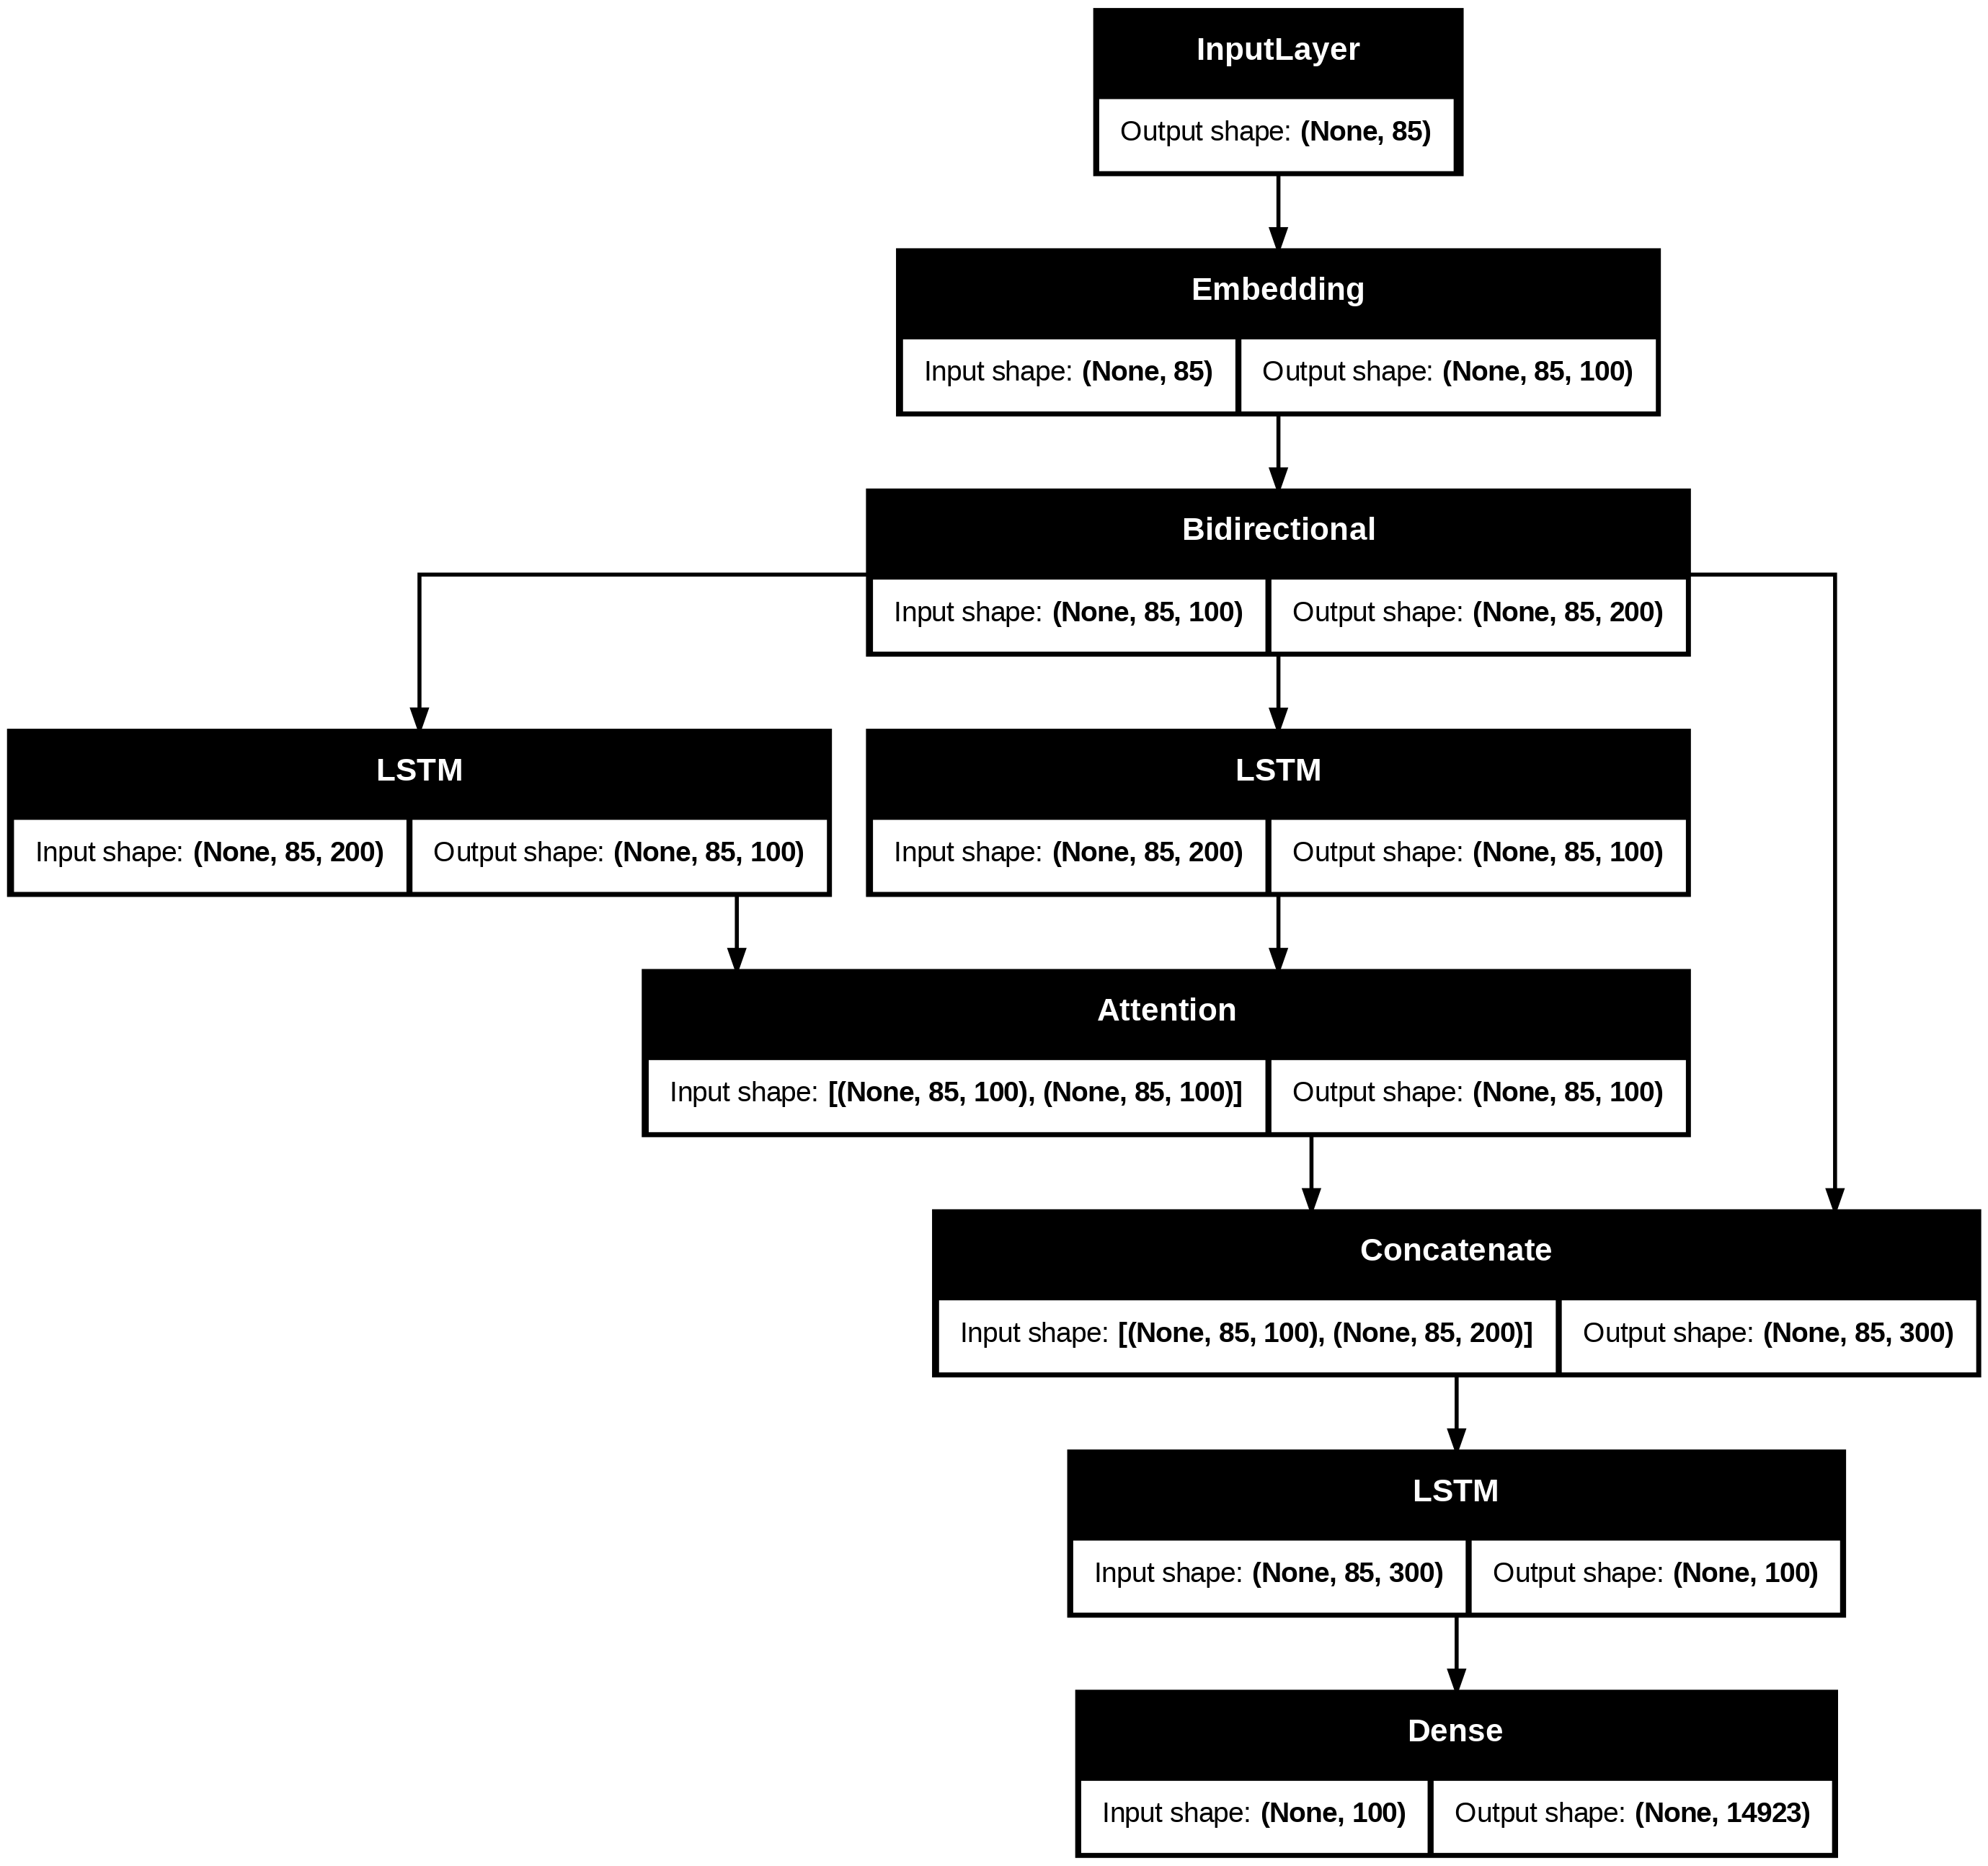

In [ ]:
# Now plot the model
from tensorflow.keras.utils import plot_model
plot_model(model_ABiLSTM, to_file='model_ABiLSTM_plot.png', show_shapes=True)
#plot_model(model_LSTM, to_file='/content/drive/My Drive/model_ALSTM_plot.png', show_shapes=True)


**Here below is to kload the generated model from google drive and the make prediction based on user input(Seed Text, number of next word to be generated)**

**We can also develop a web interface to perfom this using flask application.**

In [ ]:
import gdown

# URL with the file ID extracted
url = 'https://drive.google.com/uc?id=1-2RJPIgXLJVOwtjZQm330r5j9JmUgKkD'
output = 'model.keras'  # Name the file you want to save as
gdown.download(url, output, quiet=False)


Downloading...
From (original): https://drive.google.com/uc?id=1-2RJPIgXLJVOwtjZQm330r5j9JmUgKkD
From (redirected): https://drive.google.com/uc?id=1-2RJPIgXLJVOwtjZQm330r5j9JmUgKkD&confirm=t&uuid=fe145626-9e47-443f-a9e3-c7e2de6b8897
To: /content/model.keras
100%|██████████| 42.8M/42.8M [00:00<00:00, 133MB/s]


'model.keras'

In [ ]:
from tensorflow.keras.models import load_model

model = load_model('model.keras')


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Function to predict the next N words
def predict_next_words(model, tokenizer, seed_text, max_sequence_len, num_words):
    prediction_text = seed_text
    for _ in range(num_words):
        token_list = tokenizer.texts_to_sequences([prediction_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')
        predicted = model.predict(token_list, verbose=0)
        predicted_word = tokenizer.index_word[np.argmax(predicted)]
        prediction_text += ' ' + predicted_word
    return prediction_text

# Example usage
seed_text = "Humni qilleensaa Isiraa'el haleellaa misaayelaa fi"
num_words = 3  # User specifies how many words to predict
predicted_text = predict_next_words(model, tokenizer, seed_text, max_sequence_len, num_words)
print(f"Predicted text: {predicted_text}")


Predicted text: Humni qilleensaa Isiraa'el haleellaa  misaayelaa fi ibbiddaa


In [ ]:
seed_text = input("Enter the seed text: ")
num_words = int(input("Enter the number of words to predict: "))

predicted_text = predict_next_words(model, tokenizer, seed_text, max_sequence_len, num_words)
print(f"Predicted text: {predicted_text}")


Enter the seed text: Dhangala'uun boba'aa naafxaa
Enter the number of words to predict: 2
Predicted text: Dhangala'uun boba'aa naafxaa shaanshii chaayinaa
